# 🛒 E-Commerce Sales Analysis — 2024
**Project Type:** Option 4 – E-Commerce Sales Analysis  
**Dataset:** 100 sales transactions | Jan–Apr 2024  
**Author:** Data Analysis Project  
---


## 📦 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✅
pandas 3.0.2 | numpy 2.4.4


## 📂 2. Load & Validate Data

In [4]:
df = pd.read_csv('sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month_num'] = df['Date'].dt.to_period('M')
df['Month'] = df['Date'].dt.strftime('%b %Y')

# Validation
assert df.isnull().sum().sum() == 0, "Null values found!"
assert (df['Total_Sales'] == df['Quantity'] * df['Price']).all(), "Total_Sales mismatch!"

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"✅ No missing values | Total_Sales integrity verified")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()


✅ Dataset loaded: 100 rows × 9 columns
✅ No missing values | Total_Sales integrity verified
Date range: 2024-01-01 → 2024-04-09


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month_num,Month
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024-01,Jan 2024
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024-01,Jan 2024
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024-01,Jan 2024
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024-01,Jan 2024
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024-01,Jan 2024


## 🔍 3. Exploratory Data Analysis

In [5]:
print("=== DATASET SUMMARY ===")
print(df.describe().round(2))
print()
print("Products:", df['Product'].unique().tolist())
print("Regions:", df['Region'].unique().tolist())


=== DATASET SUMMARY ===
                      Date  Quantity     Price  Total_Sales
count                  100    100.00    100.00       100.00
mean   2024-02-19 12:00:00      4.78  25808.51    123650.48
min    2024-01-01 00:00:00      1.00   1308.00      6540.00
25%    2024-01-25 18:00:00      2.75  14965.25     39517.50
50%    2024-02-19 12:00:00      5.00  24192.00     97955.50
75%    2024-03-15 06:00:00      7.00  38682.25    175792.50
max    2024-04-09 00:00:00      9.00  49930.00    373932.00
std                    NaN      2.59  13917.63    100161.09

Products: ['Phone', 'Headphones', 'Laptop', 'Tablet', 'Monitor']
Regions: ['East', 'North', 'West', 'South']


In [6]:
# Key metrics
total_revenue = df['Total_Sales'].sum()
avg_order     = df['Total_Sales'].mean()
top_product   = df.groupby('Product')['Total_Sales'].sum().idxmax()
top_region    = df.groupby('Region')['Total_Sales'].sum().idxmax()

print(f"💰 Total Revenue      : ₹{total_revenue:,.0f}")
print(f"📦 Avg Order Value    : ₹{avg_order:,.0f}")
print(f"🏆 Best Product       : {top_product}")
print(f"🗺️  Best Region        : {top_region}")
print(f"📊 Total Transactions : {len(df)}")


💰 Total Revenue      : ₹12,365,048
📦 Avg Order Value    : ₹123,650
🏆 Best Product       : Laptop
🗺️  Best Region        : North
📊 Total Transactions : 100


## 📊 4. Visualizations

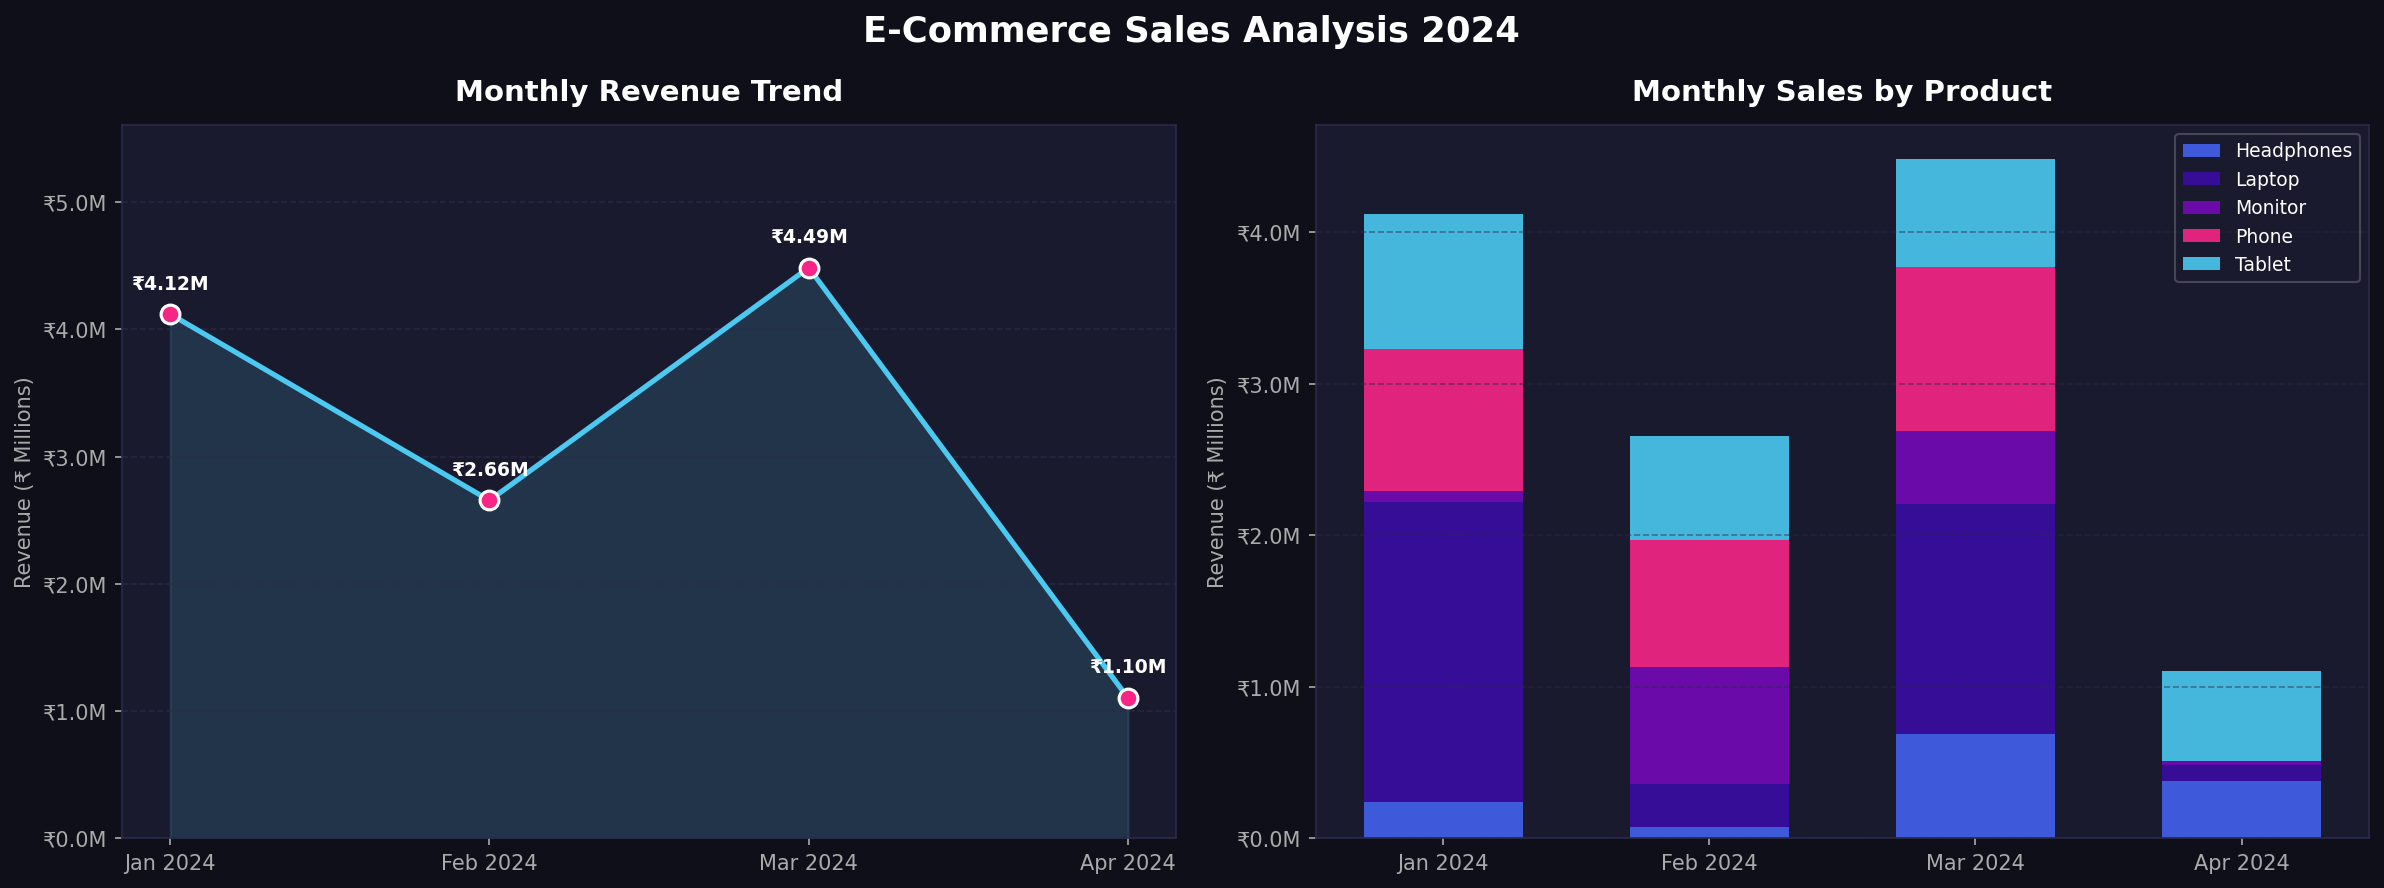

In [8]:
# All 3 charts saved in visualizations/ during project setup
# Display them here
from IPython.display import Image, display
display(Image('visualizations/chart1_revenue_trends.png'))


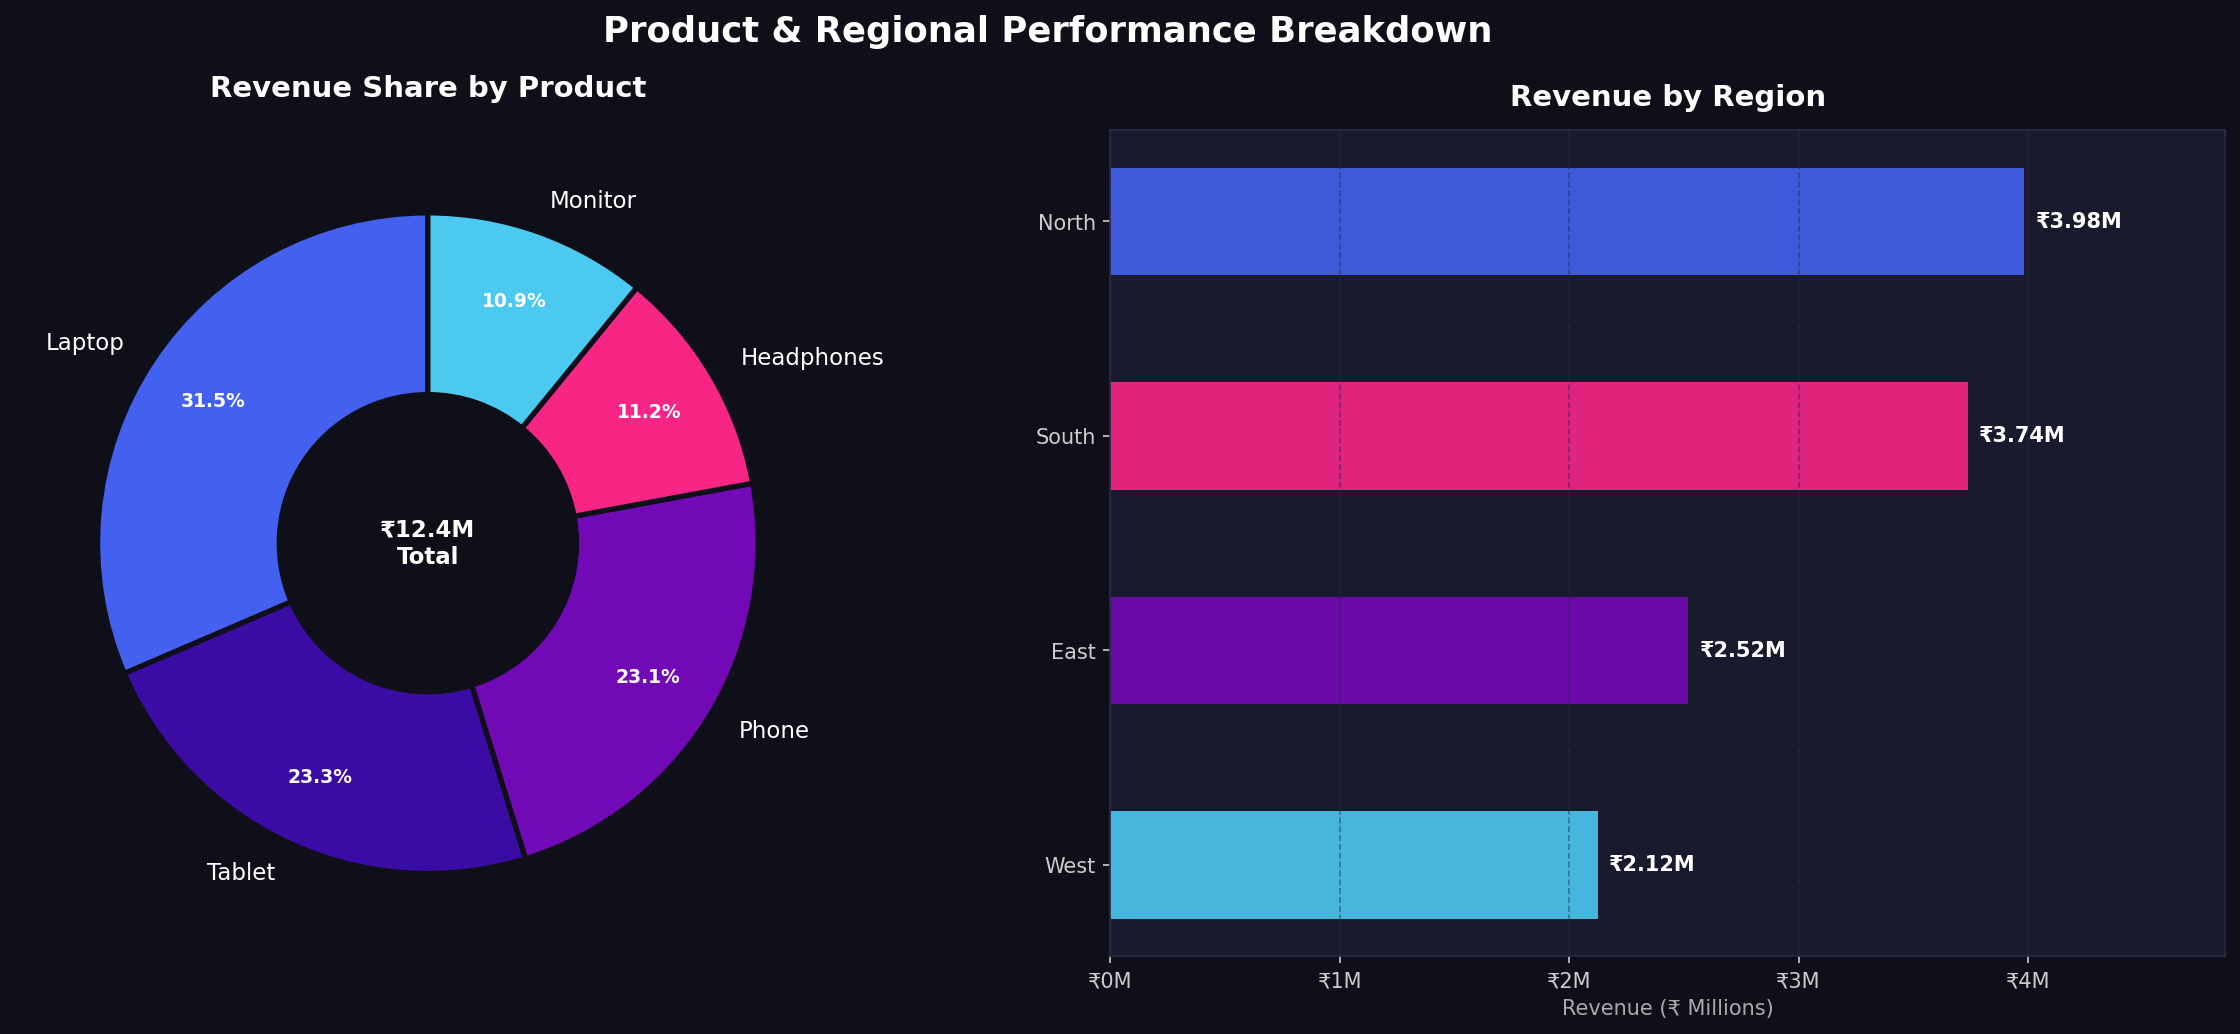

In [9]:
display(Image('visualizations/chart2_product_region.png'))


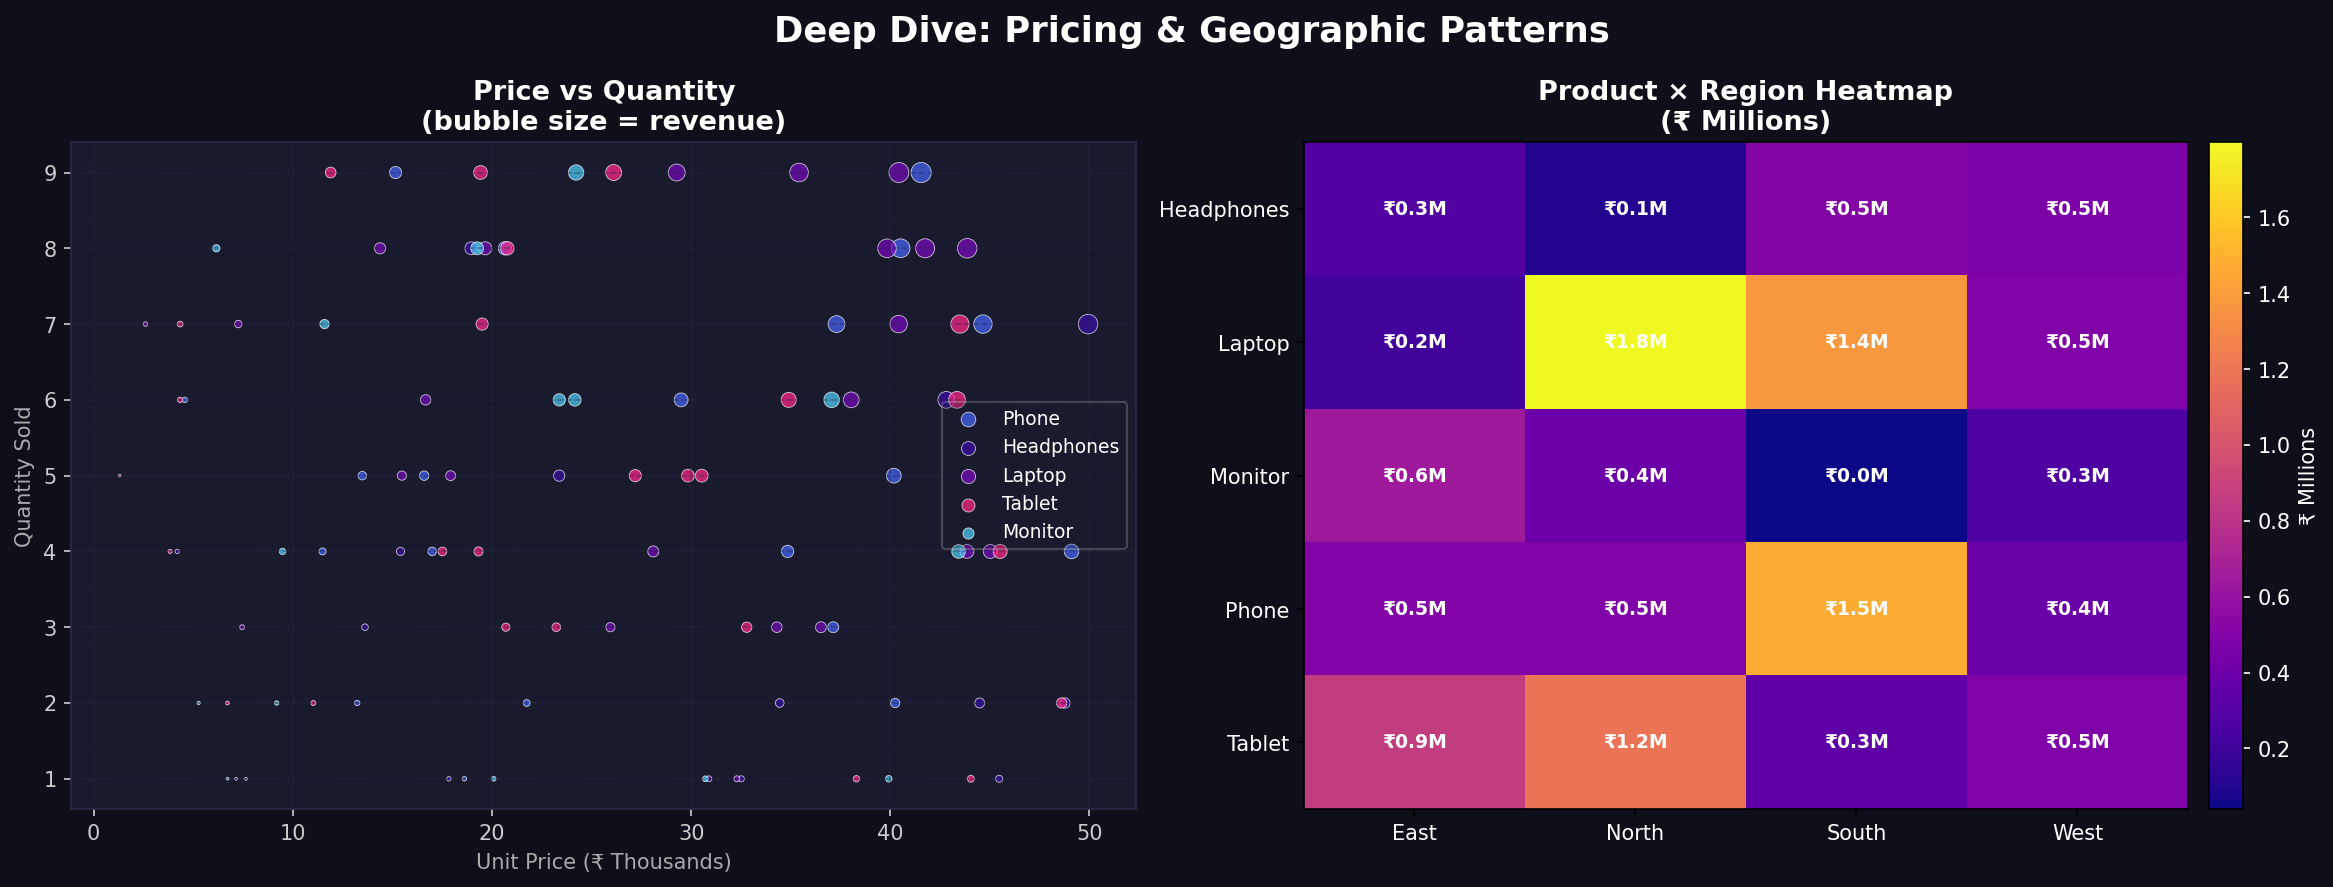

In [10]:
display(Image('visualizations/chart3_scatter_heatmap.png'))


## 💡 5. Key Insights

In [11]:
insights = {
    "Laptops lead revenue": df.groupby('Product')['Total_Sales'].sum()['Laptop'],
    "North is top region": df.groupby('Region')['Total_Sales'].sum()['North'],
    "March peak month":    df.groupby('Month_num')['Total_Sales'].sum().max(),
    "Feb slowest month":   df.groupby('Month_num')['Total_Sales'].sum().min(),
}
for k,v in insights.items():
    print(f"  → {k}: ₹{v:,.0f}")


  → Laptops lead revenue: ₹3,889,210
  → North is top region: ₹3,983,635
  → March peak month: ₹4,485,006
  → Feb slowest month: ₹1,103,468


## 📝 6. Written Insights

### 1. Laptops Dominate Revenue (32% share)
Laptops generated the highest revenue at ₹3.89M, nearly 3x that of Headphones.
Despite being a high-ticket item, they also saw strong quantities, suggesting
high demand elasticity.

### 2. March Was the Peak Sales Month
March 2024 recorded ₹4.49M in revenue — the highest monthly figure.
This spike may align with fiscal year-end purchases by B2B customers or
seasonal promotional campaigns. February was the weakest at ₹2.66M.

### 3. North & South Regions Outperform East & West
North (₹3.98M) and South (₹3.74M) together account for 65% of total revenue.
East and West lag significantly, suggesting untapped market potential or
distribution/logistics gaps in those regions.

### 4. Laptops Sold Well Across All Regions — Tablets Have a Regional Skew
The heatmap reveals Tablets performed strongly in North but weakly in East.
This regional preference could guide targeted marketing campaigns.

### 5. Price Range ₹15K–₹40K Is the Sweet Spot
The scatter plot shows most high-revenue transactions cluster between
₹15,000–₹40,000 per unit with quantities of 3–8 units, indicating
mid-to-high-tier products at moderate volumes drive the most value.

---
**Recommendation:** Invest in North/South logistics, boost Laptop inventory,
and run targeted Tablet promotions in the East region.
